<a href="https://colab.research.google.com/github/LucioFassarella/AMC/blob/main/AMC_SVM_Centroide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="red"><b>Máquina de Vetor Suporte por Centróide</b></font>

<center><img align = "center" src="https://drive.google.com/uc?export=view&id=1usXrPscUXzfQF5wNtkvuVGARuuhcgyw-" alt="grafo" width="500"></center>

<center>"You never understand things. You just get used to them." (John von Neumann)</center>


# SVM-centróide

In [24]:
def centroide(lista_vetores):
    '''
        Método que recebe uma lista de vetores (listas) e retorna o seu centróide (vetor)
    '''

    dimensao = len(lista_vetores[0])

    num_pontos = len(lista_vetores)

    if len(lista_vetores) == 0:
        raise ValueError("A lista de vetores está vazia.")

    for vetor in lista_vetores:
        if len(vetor) != dimensao:
            raise ValueError("Todas as listas devem ter a mesma dimensão.")

    centroide = [0] * dimensao

    for vetor in lista_vetores:
        for i in range(dimensao):
            centroide[i] += vetor[i]

    for i in range(dimensao):
        centroide[i] /= num_pontos

    return centroide

def svmc_treiner(lista_vetores_classificados):
    '''
        Método que recebe uma lista de vetores (listas) classificados binariamente (0 ou 1)
         e retorna o centróide de cada classe
    '''

    dimensao = len(lista_vetores_classificados[0][0])

    for vetor_classe in lista_vetores_classificados:
        vetor = vetor_classe[0]
        classe = vetor_classe[1]
        if len(vetor) != dimensao:
            raise ValueError("Todas as listas devem ter a mesma dimensão.")

        if classe != 0 and classe != 1:
            raise ValueError("Todas as classes devem ser 0 ou 1.")

    lista_vetores_0 = []
    lista_vetores_1 = []

    for vetor_classe in lista_vetores_classificados:
        if vetor_classe[1] == 0:
            lista_vetores_0.append(vetor_classe[0])
        else:
            lista_vetores_1.append(vetor_classe[0])

    centroide_0 = centroide(lista_vetores_0)
    centroide_1 = centroide(lista_vetores_1)

    return centroide_0, centroide_1


def svmc(centroide_0,centroide_1, vetor):
    '''
        Método que calcula a distância do vetor dado aos centróides 0 e 1 e
        retorna o centróide mais próximo.
    '''

    if len(centroide_0) != len(centroide_1):
        raise ValueError("Os centróides devem ter a mesma dimensão.")

    if len(centroide_0) != len(vetor):
        raise ValueError("O vetor deve ter a mesma dimensão que os centróides.")

    distancia_0 = 0
    distancia_1 = 0

    for i in range(len(centroide_0)):
        distancia_0 += (centroide_0[i] - vetor[i])**2
        distancia_1 += (centroide_1[i] - vetor[i])**2

    distancia_0 = distancia_0**0.5
    distancia_1 = distancia_1**0.5

    if distancia_0 < distancia_1:
        return 0
    else:
        return 1

In [27]:
'''
TESTES
'''

# Teste do centróide

p0 = [0,5]
p1 = [2,1]
p2 = [1,3]
centroide([p0,p1,p2])

[1.0, 3.0]

# Exemplo 1

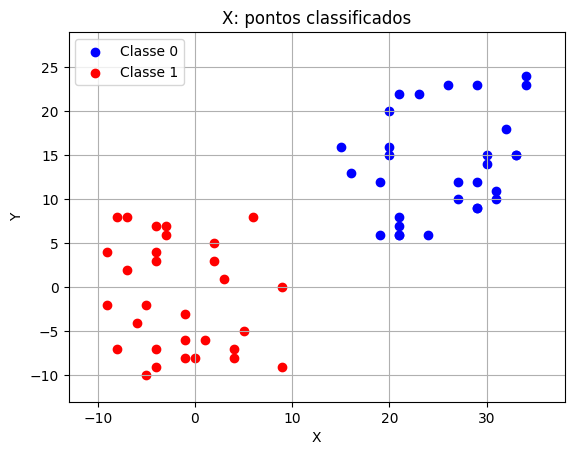

In [43]:
import random
import matplotlib.pyplot as plt

m = 30
largura = 10
a = 2.5*largura
b = 1.6*largura
X0 = [[random.randrange(-largura,largura) + a, random.randrange(-largura,largura) + b] for k in range(m)]
X1 = [[random.randrange(-largura,largura), random.randrange(-largura,largura)] for k in range(m)]

# Plot

X = X0 + X1
Y = [-1]*m + [1]*m

X0_x = [p[0] for p in X0]; X0_y = [p[1] for p in X0]

X1_x = [p[0] for p in X1]; X1_y = [p[1] for p in X1]

plt.scatter(X0_x, X0_y, color='blue', label='Classe 0')
plt.scatter(X1_x, X1_y, color='red', label='Classe 1')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('X: pontos classificados')
plt.legend()
plt.grid(True)
plt.xlim((- 3 - largura, largura + a + 3))
plt.ylim((- 3 - largura, largura + b + 3))
plt.show()

Ponto: [10, 15]. Classe: 0


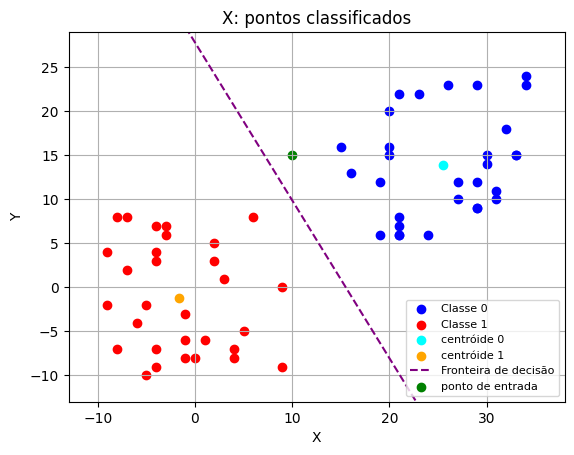

In [55]:
'''
'''

# Classes

X0_class = [[p, 0] for p in X0]
X1_class = [[p, 1] for p in X1]

X_class = X0_class + X1_class

# Centróides

centroide_0, centroide_1 = svmc_treiner(X_class)

# Ponto para classificação

p = [10,15]                                # <---- dado de entrada

classe = svmc(centroide_0, centroide_1, p) # <---- classificação

print(f"Ponto: {p}. Classe: {classe}")     # <---- impressão do resultado

######################### Plotagem

plt.scatter(X0_x, X0_y, color='blue', label='Classe 0')
plt.scatter(X1_x, X1_y, color='red', label='Classe 1')

# Centróides:

plt.scatter([centroide_0[0]],[centroide_0[1]], color = "cyan", label = "centróide 0")
plt.scatter([centroide_1[0]],[centroide_1[1]], color = "orange", label = "centróide 1")

# Fronteira de decisão (reta suporte)

    # Centróides
c0 = centroide_0
c1 = centroide_1

    # Ponto médio dos centróides
mx = (c0[0] + c1[0]) / 2
my = (c0[1] + c1[1]) / 2

    # Inclinação do vetor ligando os centróides
dx = c1[0] - c0[0]
dy = c1[1] - c0[1]

    # Figura

    # Definição da reta suporte (fronteira de decisão)

if dx == 0:  # caso em que os centróides estão em uma reta vertical
    x_line = np.linspace(-3 - largura, largura + a + 3, 100)
    y_line = np.full_like(x_line, my)
    plt.plot(x_line, y_line, color='purple', linestyle='--', label='Fronteira de decisão')
elif dy == 0: # caso em que os centróides estão em uma reta horizontal
    y_line = np.linspace(-3 - largura, largura + b + 3, 100)
    x_line = np.full_like(y_line, mx)
    plt.plot(x_line, y_line, color='purple', linestyle='..', label='Fronteira de decisão')
else:
    m_centroids = dy / dx
    m_perpendicular = -1 / m_centroids

    # Define x range for the line based on plot limits from previous cells
    x_min_plot = -3 - largura
    x_max_plot = largura + a + 3
    x_line = np.linspace(x_min_plot, x_max_plot, 100)
    y_line = m_perpendicular * (x_line - mx) + my
    plt.plot(x_line, y_line, color='purple', linestyle='--', label='Fronteira de decisão')

# Ponto de texte

plt.scatter([p[0]],[p[1]], color = "green", label = 'ponto de entrada')

# Gráfico

plt.xlabel('X')
plt.ylabel('Y')
plt.title('X: pontos classificados')
plt.legend(fontsize = '8')
plt.grid(True)
plt.xlim((- 3 - largura, largura + a + 3))
plt.ylim((- 3 - largura, largura + b + 3))
plt.show()